## Exercise Project 1 -- Linear Regression
### Dataset: [NYC Housing Prices](https://www.kaggle.com/datasets/ishank2005/nyc-housing-prices-csv)


<br>

<br>

##### Shape: `34k rows, 19 columns`

##### Target Variable: `sale_price`

##### Method: `Linear Regression`

##### Extra Tools: `Mlflow`

##### Column Descriptions (Complete):

| Column        | Description |
|--------------|-------------|
| borough_x    | *Borough code associated with the property sale record, sourced from the NYC Citywide Rolling Sales dataset.* |
| block        | *NYC tax block identifier for the property, used as part of the Borough–Block–Lot (BBL) system.* |
| lot          | *NYC tax lot identifier for the property, used as part of the Borough–Block–Lot (BBL) system.* |
| sale_price   | *Recorded sale price of the property transaction in US dollars. Non-arm’s-length and invalid transactions have been removed.* |
| zip_code     | *ZIP code of the property as recorded in the sales transaction data.* |
| borough_y    | *Borough code associated with the property tax lot, sourced from the PLUTO building dataset.* |
| yearbuilt    | *Year in which the primary structure on the tax lot was originally constructed.* |
| lotarea      | *Total land area of the tax lot, measured in square feet.* |
| bldgarea     | *Total gross building floor area on the tax lot, measured in square feet.* |
| resarea      | *Portion of the building floor area used for residential purposes, measured in square feet.* |
| comarea      | *Total commercial floor area within the building, measured in square feet.* |
| unitsres     | *Number of residential housing units on the tax lot.* |
| unitstotal   | *Total number of units on the tax lot, including residential and non-residential units.* |
| numfloors    | *Number of floors in the primary building on the tax lot.* |
| latitude     | *Latitude coordinate of the property location, expressed in decimal degrees.* |
| longitude    | *Longitude coordinate of the property location, expressed in decimal degrees.* |
| landuse      | *Numeric land use category code describing the primary use of the property (e.g., residential, commercial, mixed-use).* |
| bldgclass    | *NYC building class code indicating the structural and usage classification of the property.* |
| building_age | *Age of the building in years at the time of sale, calculated as sale year minus year built.* |


<br>
<br>



---

### Code

In [368]:
# import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PowerTransformer

# Reading the dataframe and storing it.
df = pd.read_csv("datasets/nyc_housing.csv")
df.head(5)

,borough_x,block,lot,sale_price,zip_code,borough_y,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,bldgclass,building_age
0,1,400,11,280000,10009.0,MN,1900.0,2404.0,6875.0,6875.0,0.0,18.0,18.0,5.0,40.724415,-73.983891,2.0,C6,125.0
1,1,402,36,2000000,10009.0,MN,1900.0,1919.0,7810.0,6810.0,1000.0,8.0,10.0,5.0,40.724975,-73.981535,2.0,C4,125.0
2,1,402,60,3400000,10009.0,MN,1920.0,2150.0,6152.0,5352.0,800.0,8.0,9.0,5.0,40.725346,-73.983112,4.0,C7,105.0
3,1,404,42,4000000,10009.0,MN,1855.0,2369.0,6990.0,6990.0,0.0,10.0,10.0,5.0,40.727398,-73.980600,2.0,C4,170.0
4,1,372,55,655000,10009.0,MN,1920.0,5298.0,17990.0,17990.0,0.0,20.0,20.0,5.0,40.720621,-73.979534,2.0,C6,105.0


## Cleaning

|Step|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Data Cleaning </bold>|
|2| Transformation|
|3| ML Training & Metrics|
|4|Tester Row Values|
|5| Personal Analysis |
|6| Advanced Tasks|

#### Checking The Dataframe Shape

In [369]:
# Checking the amount of columns and rows.
df.shape


(34439, 19)

#### Handling Missing Values

In [370]:
# Checking for missing values
df.isna().sum()

# A small amount of rows have missing values. 
# Getting rid of all the NaN will be trivial 200/34000 = .5% of the data. Not timeseries, so it's fine.

borough_x         0
block             0
lot               0
sale_price        0
zip_code         16
borough_y         0
yearbuilt         0
lotarea           0
bldgarea          0
resarea         188
comarea         188
unitsres          0
unitstotal        0
numfloors        43
latitude          6
longitude         6
landuse           3
bldgclass         0
building_age      0
dtype: int64

In [371]:
# Dropping nan values.
df = df.dropna()

#### Handling Duplicates

In [372]:
# Checking for duplicates
df.duplicated().value_counts()

# Some duplicates do exist. We can safely get rid of these.

False    33204
True       999
Name: count, dtype: int64

In [373]:
# Dropping the duplicate rows.
df = df.drop_duplicates()

#### Dropping Columns

Here, we'll be dropping some of the columns which we know we won't be using.




In [374]:
# Dropping co-dependent/high collinearity columns
df = df.drop(["borough_x",       # Related to borough_y
                'latitude',      # Probably just noise in the data.
                'longitude',     # Probably just noise in the data.
                'yearbuilt',     # This is co-dependent with `buildingage`
                'comarea',       # In this dataset: bldgarea = comarea + resarea. co-dependent.
                'resarea',       # In this dataset: bldgarea = comarea + resarea. co-dependent.
                'lot',           # We have borough_y. This is too specific, you'd have distributions of 1 unit being in lot ABC, hardly statistical.
                'block',         # We have borough_y, too specific. We cant have 3 units in a block be a statistical weight for an ML model.
                'zip_code',      # Too specific, it'll affect distribution.
                'landuse',       # This is often co-dependent with bldgclass (D4 bldgclass = landuse 3 for example).      
], axis=1)

# `borough_y` and `bldglclass` is categorical, we'll convert this to numbers. 
df.head(3)


,sale_price,borough_y,lotarea,bldgarea,unitsres,unitstotal,numfloors,bldgclass,building_age
0,280000,MN,2404.0,6875.0,18.0,18.0,5.0,C6,125.0
1,2000000,MN,1919.0,7810.0,8.0,10.0,5.0,C4,125.0
2,3400000,MN,2150.0,6152.0,8.0,9.0,5.0,C7,105.0


#### Categorical Feature Isolated Case Elimination

##### `bldgclass`

In [375]:
# In `bldgclass`, there are isolated cases there just isn't enough data
# to give a fair statistical weight to them.
value_counts = df['bldgclass'].value_counts().sort_values(ascending=True)
value_counts

# This eliminates any building classes that have less than 20 values. 
df = df[df['bldgclass'].isin(value_counts[value_counts >= 20].index)]

#### Categorical Feature Isolated Case Elimination

##### `borough_y`

In [376]:
# Let's check the other categorical feature, `borough_y`
df['borough_y'].value_counts()

# This seems ok! plenty of data to work with.

borough_y
QN    12619
BK     9532
SI     3842
MN     3717
BX     3221
Name: count, dtype: int64

#### Turning Categorical Columns into Numbers

In [377]:
# List of columns to convert to numbers.
categorical_columns = ["borough_y",  # Example values: MN, ME, BK
                       "bldgclass",  # Example values: C6, K4, C8
                       ]


# Converts columns into binary, separate columns.
for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)


df.head(3)

,sale_price,lotarea,bldgarea,unitsres,unitstotal,numfloors,building_age,borough_y_BK,borough_y_BX,borough_y_MN,...,bldgclass_O2,bldgclass_O5,bldgclass_O7,bldgclass_O8,bldgclass_S1,bldgclass_S2,bldgclass_S3,bldgclass_S4,bldgclass_S5,bldgclass_S9
0,280000,2404.0,6875.0,18.0,18.0,5.0,125.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,2000000,1919.0,7810.0,8.0,10.0,5.0,125.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3400000,2150.0,6152.0,8.0,9.0,5.0,105.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


---



### Transformation

|Step|Description|
|---|---|
|1| Data Cleaning|
|2| <bold style="background:yellow;color:black;">Transformation </bold>|
|3| ML Training & Metrics|
|4|Tester Row Values|
|5| Personal Analysis |
|6| Advanced Tasks|



####  Target Outlier & Skew Elimination

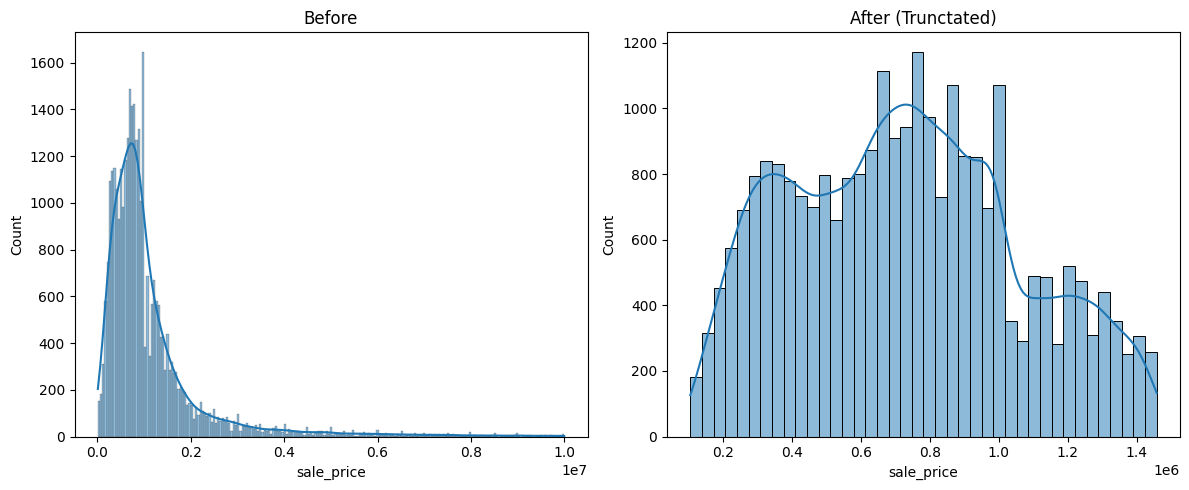

Rows left: 26016


In [378]:
# Target variable cutoffs (these constants show up in MLFLOW to track parameters of the run).
y_trunc_floor = 0.01
y_trunc_ceiling = 0.80

# Creates three canvases for histplots to show my work.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Histplot 0
sns.histplot(df, x='sale_price', ax=axes[0], kde=True)

# Truncating the Y variable.
df = df[
    (df["sale_price"] >= df["sale_price"].quantile(q=y_trunc_floor)) &
    (df["sale_price"] <= df["sale_price"].quantile(q=y_trunc_ceiling))
    ]

# Histplot 1
sns.histplot(df, x='sale_price', ax=axes[1], kde=True)

# Histplot titles
axes[0].set_title("Before")
axes[1].set_title("After (Trunctated)")
plt.tight_layout()
plt.show()


# SANITY CHECK:
# Let's check how many rows we have left.
print(f"Rows left: {df.shape[0]}")


#### Pearson Correlation


In [379]:
# Find the most correlated values. (using absolute value)
correlations = df.corr( method='pearson',numeric_only=True).sort_values(by='sale_price')
correlations = abs(correlations["sale_price"])

corr_df = pd.DataFrame(correlations).reset_index()

# Renaming the columns to make it tidy.
corr_df = corr_df.rename(columns={
    "index": "Feature",
    "sale_price": "Absolute Correlation Value"
})

# Filtering out `sale_price`
corr_df = corr_df[corr_df["Feature"] != "sale_price"]
corr_df = corr_df[corr_df["Feature"] != "sale_price"]
corr_df

,Feature,Absolute Correlation Value
0,bldgclass_D4,0.347027
1,unitsres,0.209545
2,unitstotal,0.208330
3,bldgclass_C6,0.172738
4,numfloors,0.161221
...,...,...
59,bldgclass_A1,0.071247
60,bldgclass_B3,0.099258
61,bldgclass_C0,0.108361
62,bldgclass_B1,0.117643


#### Creating a list of features

In [380]:
# This is the list we'll feed into the dataframe filter.
features_list = list(corr_df["Feature"].head(30))
features_list

['bldgclass_D4',
 'unitsres',
 'unitstotal',
 'bldgclass_C6',
 'numfloors',
 'bldgarea',
 'lotarea',
 'bldgclass_G4',
 'borough_y_BX',
 'borough_y_MN',
 'bldgclass_D1',
 'bldgclass_D3',
 'bldgclass_A6',
 'bldgclass_C7',
 'bldgclass_A8',
 'bldgclass_F9',
 'bldgclass_C5',
 'borough_y_QN',
 'bldgclass_G1',
 'bldgclass_O2',
 'bldgclass_O5',
 'bldgclass_S9',
 'bldgclass_F5',
 'bldgclass_M9',
 'bldgclass_O7',
 'bldgclass_D6',
 'bldgclass_C4',
 'bldgclass_A9',
 'bldgclass_G9',
 'bldgclass_E1']

#### Checking for Feature Independence (via Correlation Heatmap)

Our last step for selecting these features is to be sure that these features are independent from one-another. We're going to do this via using a correlation heatmap. We'll only be looking at `X`, meaning the feature candidates that we could be using to predict the target variable `Y`.

<Axes: >

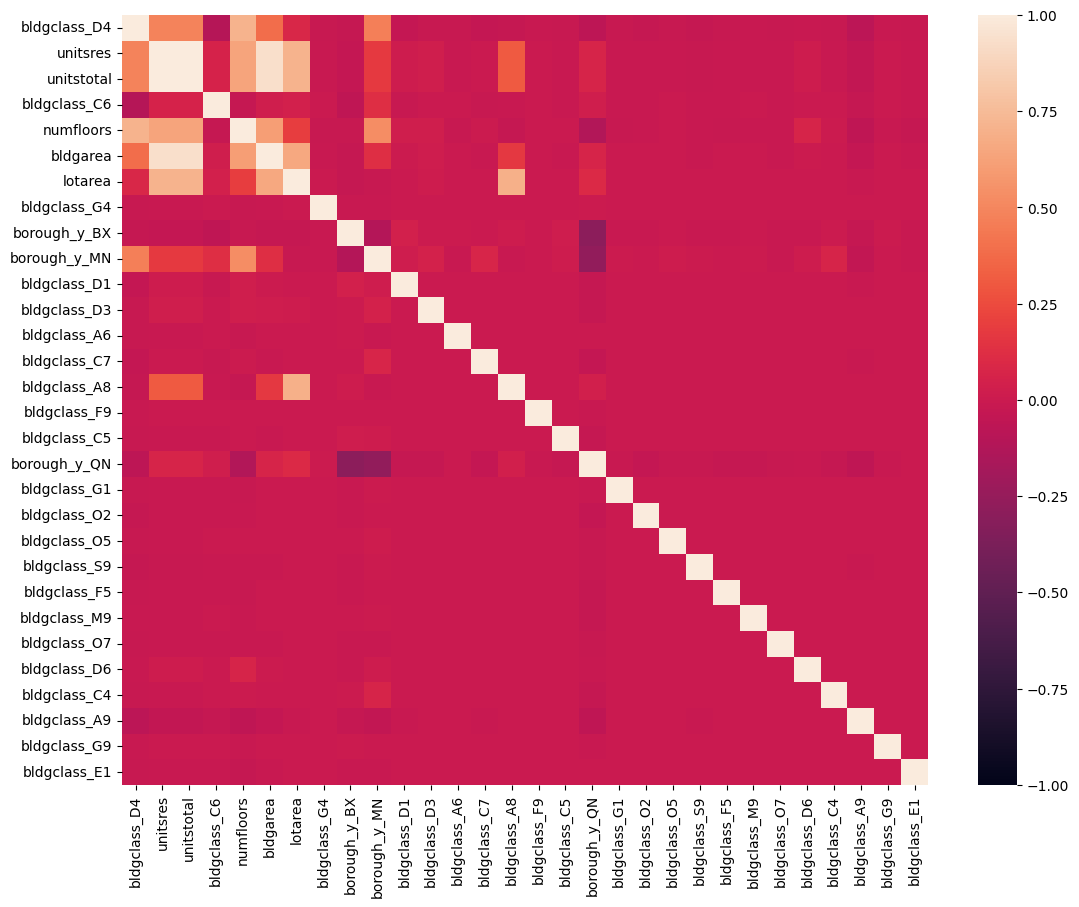

In [381]:
correlation = df[features_list].corr(numeric_only=True)
plt.figure(figsize=(13,10))
sns.heatmap(correlation, vmin=-1, vmax=1)

# I took the annotations out for readability.

#### 

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

<h3>Observations</h3>

We have a problem, some of these features corrolate way too much with one-another.

|Correlation Value| Feature A | Feature B|
|---|---|---|
|_1.0_|`unitsres`|`unitstotal`|
|_0.93_|`unitsres`|`bldgarea`|
|_0.93_|`unitsres`|`bldgarea`|

This is multi-collinearity and we'll need to get rid of a couple of these features before continuing.


</div>

In [382]:
# Removing these co-dependent features from the features list.
# features_list.remove("unitsres")
# features_list.remove("unitstotal")
features_list

['bldgclass_D4',
 'unitsres',
 'unitstotal',
 'bldgclass_C6',
 'numfloors',
 'bldgarea',
 'lotarea',
 'bldgclass_G4',
 'borough_y_BX',
 'borough_y_MN',
 'bldgclass_D1',
 'bldgclass_D3',
 'bldgclass_A6',
 'bldgclass_C7',
 'bldgclass_A8',
 'bldgclass_F9',
 'bldgclass_C5',
 'borough_y_QN',
 'bldgclass_G1',
 'bldgclass_O2',
 'bldgclass_O5',
 'bldgclass_S9',
 'bldgclass_F5',
 'bldgclass_M9',
 'bldgclass_O7',
 'bldgclass_D6',
 'bldgclass_C4',
 'bldgclass_A9',
 'bldgclass_G9',
 'bldgclass_E1']

---

### ML Implementation

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|<bold style="background:yellow;color:black;">ML Training & Metrics</bold>|
|4| Tester Row Values|
|5| Personal Analysis|
|6| Advanced Tasks|


#### `LinearRegression` ML Model Training & Logging

If you've been paying attention, you may have noticed us using constants a lot. That's for `mlflow` an MLOPS tool.
In this case, I'll be using it to log and track parameters so I know what optimization changes have been working with this dataset.

If you're curious:

|step|instructions|
|---|---|
|1| Run the cell below|
|2| Type `mlflow ui` in the venv's command prompt and open your browser to http://localhost:5000/.|
|3| You can see the parameters and metrics for each run performed locally in the `ex1_project_a` mlruns section.|

Otherwise, feel free to skip all this. It runs just like normal.








In [383]:
from sklearn.feature_selection import RFE

# Constants (These are used to log the parameters in mlflow, that way I can remember what works)
XY_SPLIT = 0.3

# Defining dependent, independent variables.
X = df[features_list]
y = df['sale_price']

# train/test-split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=XY_SPLIT, random_state=101)


# Initalize and fit the model.
lm = LinearRegression()
lm.fit(X_train, y_train)

# Find the intercept value of the regression.
intercept = lm.intercept_

# Create a list of coefficients for each feature.
coefs = lm.coef_
print(coefs)

# Predict the data with the model.
predictions = lm.predict(X_test)



# -- METRICS RECORDING -- 
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r_sq = metrics.r2_score(y_test, predictions)



[-4.48209023e+05 -5.79870799e+02  1.56259194e+02 -4.03997280e+05
  1.36535143e+04  9.67260339e-02  5.51741413e-02 -4.95466935e+05
 -4.78921970e+04  1.84353943e+05 -2.64047413e+05 -5.02566120e+05
 -3.10599375e+05 -2.46003534e+05 -1.42587884e+05 -2.52832825e+05
 -2.49806223e+05  5.57449255e+03 -1.82638484e+05 -1.95483073e+05
 -2.51079932e+05 -1.81847463e+05 -1.17614088e+05 -1.82456240e+05
 -1.31414059e+05 -2.41785976e+05 -2.55764489e+05 -9.72717093e+04
 -1.10787619e+05 -8.00921265e+04]


#### Metric & Parameter Prints

In [384]:
# -- METRICS RECORDING -- 
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r_sq = metrics.r2_score(y_test, predictions)


# -- PRINT METRICS --
print("METRICS")
print("--------------------------")
print("MAE")
print(f"{round(mae,2)} \n")
print("MSE")
print(f"{round(mse,2)} \n")
print("RMSE")
print(f"{round(rmse,2)} \n")
print('R-squared:')
print(f"{round(r_sq,2)} \n")

# -- PRINT PARAMETERS
print("PARAMETERS")
print("--------------------------")
print("Target Variable Truncation Amount:")
print(f"{y_trunc_floor, y_trunc_ceiling} \n")
print("X,Y Split:")
print(f"{XY_SPLIT}\n")

METRICS
--------------------------
MAE
226661.25 

MSE
81734152220.48 

RMSE
285891.85 

R-squared:
0.23 

PARAMETERS
--------------------------
Target Variable Truncation Amount:
(0.01, 0.8) 

X,Y Split:
0.3



#### Scatterplot Linearity Test

<Axes: xlabel='sale_price'>

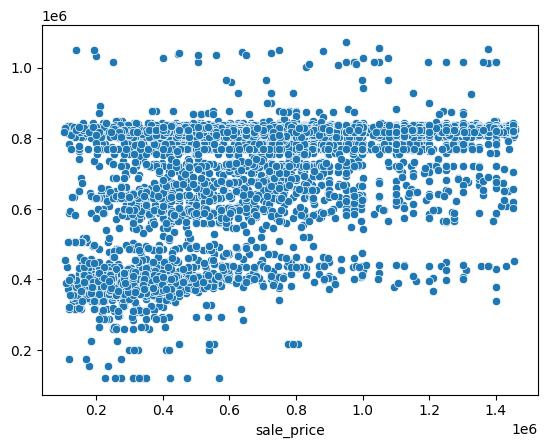

In [385]:
# If these values follow a line = good predictions
sns.scatterplot(x=y_test, y=predictions)

---

#### Creating a DataFrame to Compare Individual `sale_price` with `error_margin`

Let's create a dataframe we can compare the `sale_price` to the prediction results more easily.

### Testing with Imaginary Values

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3| ML Training & Metrics|
|4| <bold style="background:yellow;color:black;">Tester Row Values</bold>|
|5| Personal Analysis |
|6|GUI Application|
|7| Advanced Tasks|


Here, we'll create an example prediction dictionary row. I can refer to this when I create my GUI.

In [386]:
# tester_row = {
#        'bldgclass_D4' : 1,
#        'bldgclass_C6' : 0,
#        'numfloors' : 5, 
#        'bldgarea' : 1700,
#        'lotarea' : 2100,
#        'borough_y_MN' : 0,
#        'bldgclass_G4' : 0,
#        'bldgclass_D1' : 1,
#        'bldgclass_D3' : 0,
#        'bldgclass_A6' : 0,
#        'bldgclass_C7': 0,
#        'borough_y_QN': 0,
#        'bldgclass_S9': 0,
#        'bldgclass_C5': 0,
#        'borough_y_BX': 1,
#        'bldgclass_F9': 0,
#        'bldgclass_K1': 0,
#        'bldgclass_G1': 0,
#        'bldgclass_F5': 0,
#        'bldgclass_O2': 0,
#        'bldgclass_O5': 0,
#        'bldgclass_O7': 0,
#        'bldgclass_D7': 0,
#        'bldgclass_D6': 0,
#        'bldgclass_A8': 0,
#        'bldgclass_E9': 0,
#        'bldgclass_G9': 0,
#        'bldgclass_M9': 0
# }

# # Convert to pandas format
# tester_row = pd.DataFrame([tester_row])

# # Get the output/result from the model
# # Based on the user's given new data 
# result = lm.predict(tester_row)[0]

# print()
# print(f"Predicted price for this home:")
# print(f"$ {round(float(result), 2)}")
# print("----------------------------")

# # Well, it's a valid number!

---

### Personal Analysis

<br>

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|ML Training & Metrics|
|4| Tester Row Values|
|5|<bold style="background:yellow;color:black;"> Personal Analysis </bold>|
|6|Model Application|
|7| Advanced Tasks|

<br>
<br>
<br>

In my personal analysis, I'll be performing the following process:

|Step|Description|
|---|---|
|1| Create a dataframe which can easily compare the `predicted_price` with the `sale_price`.|
|2| (I do research here)|
|3| Give some post-research observations.|

<br>
<br>
<br>


#### Creating a Dataframe with `predicted_price` and `error_margin`

Creating a dataframe that easily lets us check the results in one dataframe.

In [ ]:
# Adding a column to the dataframe which predicted the price.
case_df = df
case_df['predicted_price'] = lm.predict(X).round(2)

# Creating an error margin column for the price for each row.
case_df["error_margin"] = abs(df["sale_price"] - df['predicted_price']).round(2)

case_df = case_df.sort_values("error_margin", ascending=False)

# Here, we can see some of the extreme cases with high error margins.
# NOTE: `error_margin` and `predicted_price` is at the end of the dataset

In [401]:
case_df.head(10)

,sale_price,lotarea,bldgarea,unitsres,unitstotal,numfloors,building_age,borough_y_BK,borough_y_BX,borough_y_MN,...,bldgclass_O7,bldgclass_O8,bldgclass_S1,bldgclass_S2,bldgclass_S3,bldgclass_S4,bldgclass_S5,bldgclass_S9,predicted_price,error_margin
4039,1400000,138122.0,399204.0,394.0,396.0,6.0,73.0,0,0,0,...,0,0,0,0,0,0,0,0,309641.78,1090358.22
5969,1400000,2861.0,8996.0,10.0,10.0,4.0,7.0,1,0,0,...,0,0,0,0,0,0,0,0,339551.32,1060448.68
12186,1450000,5985.0,24918.0,19.0,19.0,6.0,96.0,1,0,0,...,0,0,0,0,0,0,0,0,419115.37,1030884.63
17609,1415000,11851.0,29000.0,32.0,32.0,4.0,123.0,1,0,0,...,0,0,0,0,0,0,0,0,387019.88,1027980.12
17765,1450000,3240.0,9540.0,6.0,9.0,3.0,105.0,1,0,0,...,0,0,0,0,0,0,0,0,426703.40,1023296.60
12299,1400000,37000.0,143418.0,144.0,144.0,6.0,109.0,1,0,0,...,0,0,0,0,0,0,0,0,379337.18,1020662.82
17517,1455000,2067.0,6296.0,5.0,5.0,5.0,35.0,1,0,0,...,0,0,0,0,0,0,0,0,453586.76,1001413.24
12302,1377500,37000.0,143418.0,144.0,144.0,6.0,109.0,1,0,0,...,0,0,0,0,0,0,0,0,379337.18,998162.82
23199,1350000,26160.0,77760.0,78.0,78.0,6.0,70.0,0,1,0,...,0,0,0,0,0,0,0,0,352454.43,997545.57
13065,1425000,2100.0,5016.0,5.0,5.0,3.5,125.0,1,0,0,...,0,0,0,0,0,0,0,0,432984.50,992015.50


<h3>Post-Research Observations: </h3>

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

<i>

I experimented by putting in a new model, `RandomForestRegressor` to see if it would give me improvements.
The results for `RandomForestRegressor` were only marginally better than `LinearRegression`. Here are the results:

</i>

<br>


|Random Forest Regressor Scatterplot (y-test, prediction)| Random Forest Regressor Performance Metrics|
|---|---|
|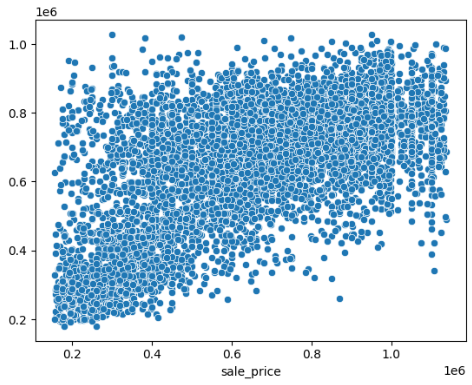|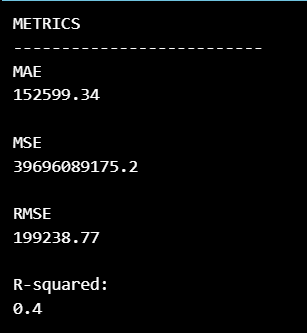|

I've done some research and some work related to WHY the performance metrics are so low with this particular dataset.

<br>
<i>
<strong style='color:orange ; background-color:black;'>
  TLDR: It's a dataset issue.
</strong></i>

<b>Reasoning:</b>

<i>
<b>We're missing a key feature when it comes to NYC housing -- Maintenance contracts.</b>

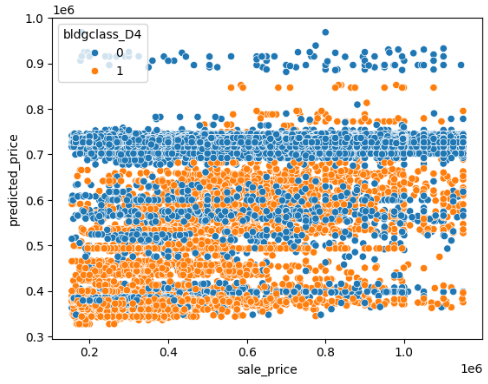

 Just like in Finland,
many homes are part of housing associations or come with a maintenance contract, which affect the price HEAVILY. These maintenance contracts 
correlate negatively with the sales price of the home/apartment (higher maintenance cost, lower home price).
 Look at the example below so you get an idea of what I mean. Assume that these two homes are the same just with different maintenance contracts/costs.
But say that they have different maintenance contracts.

</i>

<b>Example:</b>

|House|House Price| Maintenance Cost/month|
|---|---|---|
|1| 400,000| 1,200|
|2| 1,000,000| 300|

<br>
<i>

`bldgclass_D4` is an apartment co-op building class, which are homes that are notorious for having high variance in these maintenance fees. 

Therefore, since price of the home is heavily correlated by the maintenance cost and since we do not have this `maintenance_costs/mo` in the dataset and
cannot easily retrieve it, the dataset is likely inherently flawed no matter how much optimization I use. Another complication is that this dataset isn't home-prices, but <b>lot </b> prices (commercial and residential), which is likely more complicated because
it means both individual homes and entire apt complexes are in the dataset. Also, that makes the price differences between lots huge.

NOW, if you're wondering "Regarding the maintenance costs, why doesn't this maintenance variance show up on other kaggle datasets?" 

Well that's because this dataset is for NYC house prices. New York City is a cold climate. You don't typically see this much maintenance expense in California unless you're living under an HOA.

<b>Overall Thoughts </b>

Pretty frustrating dataset. I've spent around 30 hours on this exercise. I've tried various transformations, used various selection methods like RFE, SelectKBest, Fischer. What worked the best was the simplest methods.
The optimal result was to throw over thirty columns of features at it, which seems antithetical to the approach.

</i>

<b>Sources:</b> 

<i>
If you'd like to see how I made reached this conclusion:
</i>
<br>
<br>

|Number|Source|
|---|---|
|1|[A forum discussing the maintenance cost & resale price](https://streeteasy.com/talk/discussion/40799-should-i-be-scared-away-by-high-maintenance-fee)
|2|[A paper that not-so-briefly discusses the complexity of the problem](https://arxiv.org/pdf/2007.01171)

</div>


---

### GUI Application

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|ML Training & Metrics|
|4| Tester Row Values|
|5| Personal Analysis|
|6| <bold style="background:yellow;color:black;">GUI Application</bold>|
|7| Advanced Tasks|

In this model application, we'll create a <strong> GUI that allows the user to enter NYC home characteristics and give a predicted lot price</strong>
and parameters for their home and it will spit out a predicted price. We'll be using `gradio` for this application. I chose this app because it has webdev-like features
and we can run it as the output in a jupyter-notebook cell(nice and quick to test.).

### <strong style='color:red ; background-color:black;'>FULL DISCLOSURE: I AM USING AI.</strong>

<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

#### What is AI generated?

_The two lists at the beginning. I couldn't be bothered to write them myself._
<br>


#### LLM:

_ChatGPT 5.0_ 

</div>


In [389]:
features_list

['bldgclass_D4',
 'unitsres',
 'unitstotal',
 'bldgclass_C6',
 'numfloors',
 'bldgarea',
 'lotarea',
 'bldgclass_G4',
 'borough_y_BX',
 'borough_y_MN',
 'bldgclass_D1',
 'bldgclass_D3',
 'bldgclass_A6',
 'bldgclass_C7',
 'bldgclass_A8',
 'bldgclass_F9',
 'bldgclass_C5',
 'borough_y_QN',
 'bldgclass_G1',
 'bldgclass_O2',
 'bldgclass_O5',
 'bldgclass_S9',
 'bldgclass_F5',
 'bldgclass_M9',
 'bldgclass_O7',
 'bldgclass_D6',
 'bldgclass_C4',
 'bldgclass_A9',
 'bldgclass_G9',
 'bldgclass_E1']

In [390]:
import gradio as gr


# We use these to create key-value pairs with conditional logic. 
bldg_classes = ['A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A8', 'A9',
            'B1', 'B2', 'B3', 'B9','C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'D0', 
            'D1', 'D3', 'D4', 'D6', 'D7', 'E1', 'E9','F4', 'F5', 'F9','G1', 'G2', 'G4', 
            'G8', 'G9', 'K1', 'K2', 'K4', 'K7', 'M1', 'M9', 'O2', 'O5', 'O7', 'O8', 'S1',
            'S2', 'S3', 'S4', 'S5', 'S9']

boroughs = ["BK", "BX", "MN", "QN", "SI"]

# This function interprets the values submitted from the user in the gradio app and predicts the result.
def predict(borough, bldg_class, lotarea, bldgarea, 
    unitsres, unitstotal, numfloors, building_age):

    # First, we're going to create a dict. Notice it's incomplete! See the next step.
    tester_row = {
    'lotarea': lotarea, 'bldgarea': bldgarea,
    'unitsres': unitsres, 'unitstotal': unitstotal,
    'numfloors': numfloors, 'building_age': building_age,
    }

    # Next, this loop will add all the boroughs in the `tester_row` dictionary...

    # If the user-selected borough matches the bourough iteration in the list...
    # give a value of 1. Otherwise, give the value 0.
    # Then, add it as a key:value pair in the `tester_row` dict.
    for b in boroughs:
        borough_key = f"borough_y_{b}"

        if b == borough:
            tester_row[borough_key] = 1
        else:
            tester_row[borough_key] = 0

    # Same as above, except classes edition, baby!
    for c in bldg_classes:
        bldgclass_key = f"bldgclass_{c}"

        if c == bldg_class:
            tester_row[bldgclass_key] = 1
        else:
            tester_row[bldgclass_key] = 0
  
    # Transform the dict into a dataframe, and predict the user's output.
    tester_row = pd.DataFrame([tester_row])
    result = lm.predict(tester_row)[0]
    result = result.round(2)
    
    return result

# Use Gradio Blocks to create a GUI! This should show up in the output cell.
# NOTE: Click the `local URL` link for it to appear in your web-browser, if you prefer. 

with gr.Blocks() as house_lot_prediction:

    gr.Markdown("## NYC Home Price Predictor")
    gr.Markdown("### Enter Property Details")

    # Input options
    select_borough = gr.Dropdown(choices=boroughs, label="Which Borough do you live in?")
    select_class = gr.Dropdown(choices=bldg_classes, label="What building class does your lot have?")
    select_lotarea = gr.Number(label="How big is your plot of land? (freedom units please)")
    select_bldgarea = gr.Number(label="How much building area is on your plot of land? (freedom units please)")
    select_numfloors = gr.Slider(label="What's the maximum number of floors on your plot of land?", minimum=1, maximum=104)
    select_building_age =gr.Slider(label="How old, on average, is your buildings?", minimum=0, maximum=250)

    gr.Markdown("### Prediction")

    # Prediction output and submit button
    outputs = gr.Number(label="Home Price")
    submit = gr.Button("Predict Price")

    # Click action functionality
    submit.click(
        fn=predict,
        inputs=[
            select_borough, select_class, select_lotarea,
            select_bldgarea,  select_numfloors, select_building_age
            ],
        outputs=outputs
    )

house_lot_prediction.launch()

# If you don't see the submit button, keep scrolling. It's there!

c:\Users\kykis\Intro_ML\.venv\Lib\site-packages\gradio\utils.py:1171: UserWarning: Expected 8 arguments for function <function predict at 0x000001E190C80680>, received 6.
  warnings.warn(
c:\Users\kykis\Intro_ML\.venv\Lib\site-packages\gradio\utils.py:1175: UserWarning: Expected at least 8 arguments for function <function predict at 0x000001E190C80680>, received 6.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7867
* To create a public link, set `share=True` in `launch()`.


---

## Advanced Tasks

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|ML Training & Metrics|
|4| Tester Row Values|
|5| Personal Analysis|
|6| GUI Application|
|7| <bold style="background:yellow;color:black;">Advanced Tasks </bold>|

<br>
<br>

#### Advanced Task Contents


|Task|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Experiment with polynomial and curve fitting features of `scikit-learn` with any dataset. Explain your findings in your Jupyter notebook, and analyze how useful they are.</bold>|
|2|Write down the multiple linear regression formula of your model by using the `intercept-` and `coeff–` variables in your model `–object`.|
|3|You can also consider using other regressors like `CatBoostRegressor` which allows you to use other types of data than numbers without transformations. Write down your experiences with this regressor.|

<br>
<br>

### Adv. Task 1 -- Polynomial, Curve-fitting feature experimentation

### _[Link to Notebook](ex1_project.ipynb)_

<br>

### Adv. Task 2 -- Print the Poly-Linear Regression



|Task|Description|
|---|---|
|1|Experiment with polynomial and curve fitting features of `scikit-learn` with any dataset. Explain your findings in your Jupyter notebook, and analyze how useful they are.|
|2|<bold style="background:yellow;color:black;"> Write down the multiple linear regression formula of your model by using the `intercept-` and `coeff–` variables in your model `–object`.</bold>|
|3|You can also consider using other regressors like `CatBoostRegressor` which allows you to use other types of data than numbers without transformations. Write down your experiences with this regressor.|

This shouldn't be terribly hard, especially since the intercept and coefficient are literally given as 
`intercept-` and `coeff-`. The only REAL issue is that we have so many features that we'll need to creative with naming the variables.

In [391]:
# The strategy will be to append a string with it's coefficients.
# IE: "Jere" + "my" = "Jeremy"

# First, we'll turn the coefficients into a list.
# This makes it easier to iterate over.
coefs_list = coefs.tolist()

# Second, we create a number translator for subscripts.
sub = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")

# Third, we create the string variable, startying with ` y =`
regression_string = "y = "

# Fourth, initiate a loop which will append to the string above.
# The `enumerate` in the loop will let me call the VALUE and the INDEX.
# The index will be used to generate new variable names.
# The value, `coef`, will let us call the weight.
# IE: WeightX₁ + WeightX₂ WeightX₃ 
for  index, coef in enumerate(coefs_list):
    index += 1
    index = str(index).translate(sub)
    coef = round(coef,2)

    regression_string += f"{coef}x{index} + " 

regression_string += str(intercept)
print(regression_string)


y = -448209.02x₁ + -579.87x₂ + 156.26x₃ + -403997.28x₄ + 13653.51x₅ + 0.1x₆ + 0.06x₇ + -495466.94x₈ + -47892.2x₉ + 184353.94x₁₀ + -264047.41x₁₁ + -502566.12x₁₂ + -310599.38x₁₃ + -246003.53x₁₄ + -142587.88x₁₅ + -252832.83x₁₆ + -249806.22x₁₇ + 5574.49x₁₈ + -182638.48x₁₉ + -195483.07x₂₀ + -251079.93x₂₁ + -181847.46x₂₂ + -117614.09x₂₃ + -182456.24x₂₄ + -131414.06x₂₅ + -241785.98x₂₆ + -255764.49x₂₇ + -97271.71x₂₈ + -110787.62x₂₉ + -80092.13x₃₀ + 790711.4952824928


### Adv. Task 3 -- Using `CatBoostRegressor`

_New notebook for this_